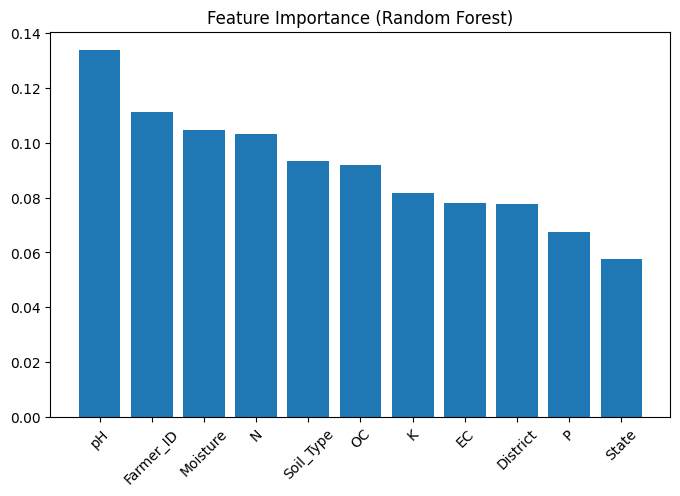

In [6]:
import matplotlib.pyplot as plt
import numpy as np

feature_importance = best_model.feature_importances_
features = X.columns

indices = np.argsort(feature_importance)[::-1]
plt.figure(figsize=(8,5))
plt.bar(range(len(features)), feature_importance[indices])
plt.xticks(range(len(features)), np.array(features)[indices], rotation=45)
plt.title("Feature Importance (Random Forest)")
plt.show()


In [5]:
import joblib

# Save best model (Random Forest)
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
joblib.dump(best_model, '../data/processed/best_model.pkl')

# Save accuracy report
best_acc = results["Random Forest"]
with open('../data/processed/model_accuracy_report.txt', 'w') as f:
    f.write(f"Best Model: Random Forest\nAccuracy: {best_acc:.2f}\n")

print("✅ Model and accuracy report saved successfully!")


✅ Model and accuracy report saved successfully!


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n✅ {name} trained successfully!")
    print(f"🎯 Accuracy: {acc:.2f}")
    print(classification_report(y_test, y_pred))



✅ Random Forest trained successfully!
🎯 Accuracy: 0.60
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         1
           3       1.00      0.50      0.67         2
           4       0.60      1.00      0.75         3
           5       1.00      1.00      1.00         1

    accuracy                           0.60        10
   macro avg       0.60      0.58      0.57        10
weighted avg       0.58      0.60      0.56        10


✅ Logistic Regression trained successfully!
🎯 Accuracy: 0.40
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         1
           3       0.33      0.50      0.40         2
           4       0.50      0.67      0.57         3
           5  

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Fra

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv('../data/processed/soil_reduced_features.csv')

# Initialize encoder
le = LabelEncoder()

# Identify object (string) columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Encode all categorical columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Separate features and target
X = df.drop(columns=['Crop_Suitability'])
y = df['Crop_Suitability']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ All categorical columns encoded successfully!")
print("Categorical columns encoded:", list(categorical_cols))
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


✅ All categorical columns encoded successfully!
Categorical columns encoded: ['State', 'District', 'Farmer_ID', 'Soil_Type', 'Crop_Suitability']
Training set shape: (40, 11)
Test set shape: (10, 11)


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load dataset from Member 3
df = pd.read_csv('../data/processed/soil_reduced_features.csv')

# Encode categorical columns
le = LabelEncoder()
df['Soil_Type'] = le.fit_transform(df['Soil_Type'])
df['Crop_Suitability'] = le.fit_transform(df['Crop_Suitability'])

# Separate features and target
X = df.drop(columns=['Crop_Suitability'])
y = df['Crop_Suitability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("✅ Data loaded and split successfully!")


✅ Data loaded and split successfully!
